In [1]:
# IMPORTS
import os, sys, json
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import torch
import optuna

import neuropythy as ny

import visual_autolabel as va
import visual_autolabel.benson2025 as project
from visual_autolabel.benson2025.hcp import HCPDataset

mkdir -p failed for path /home/jovyan/.cache/matplotlib: [Errno 30] Read-only file system: '/home/jovyan/.cache/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-62nagdbg because there was an issue with the default path (/home/jovyan/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# MANUALLY CONFIGURING NEUROPYTHY PATHS, JUST IN CASE. 
ny.config["freesurfer_subject_paths"] =  "/gscratch/nbenlab/data/freesurfer/subjects"
ny.config["data_cache_root"] = "/gscratch/nbenlab/data/neuropythy"
ny.config["hcp_subject_paths"] = "/gscratch/nbenlab/data/hcp/subjects"
ny.config["hcp_auto_download"] = True
ny.config["hcp_lines_path"] = "/gscratch/nbenlab/data/hcp/lines"
ny.config["hcp_metadata_path"] = "/gscratch/nbenlab/data/hcp/meta"
ny.config["visual_performance_fields_path"] = "/gscratch/nbenlab/data/performance-fields"

In [3]:
# CONFIGURING VISUAL AUTOLABEL PATHS. 
data_root = '/gscratch/nbenlab/data/visual-autolabel'
dataset_cache_path = f'{data_root}/datasets/'
model_cache_path = f'{data_root}/models'
figures_path = f'{data_root}/figures'

project.config.dataset_cache_path = dataset_cache_path
project.config.model_cache_path = model_cache_path
project.config.figures_path = figures_path

In [4]:
# NOT THE DATASET WE ARE WORKING ON. 
val = np.array([115017, 126426, 134829, 146735, 169444, 171633, 172130, 176542,
        177140, 182739, 185442, 192641, 195041, 198653, 204521, 209228,
        212419, 239136, 246133, 263436, 320826, 360030, 380036, 389357,
        581450, 585256, 601127, 765864, 782561, 789373, 825048, 871762,
        901442])

In [ ]:
# sid = 182739
# hem = 'lh'

# labels_gold = ny.load(f'/gscratch/nbenlab/data/hcp/labels/visual/{hem}.{sid}.mgz')

In [5]:
# WEIGHTS OF THE BEST MODEL FROM THE OPTUNA RUN
weights_file = f'/gscratch/nbenlab/data/visual-autolabel/models/hv4_VO1_VO2_funcplan2/best_trac.pt'

In [6]:
# LOADING BEST MODEL FROM OPTUNA RUN
weights = torch.load(weights_file, weights_only=True, map_location=torch.device('cpu'))
model = va.UNet(feature_count=9, segment_count=3)
model.load_state_dict(weights)

<All keys matched successfully>

In [7]:
im = HCPDataset(
    inputs='trac',
    outputs='area',
    sids=val,
    cache_path = os.path.join(dataset_cache_path, 'HCP'),
    hemis='lr'
)

In [ ]:
# sid = 115017
# ny.config = "/gscratch/nbenlab/data/hcp/subjects"
# sub = ny.data['hcp_lines'].subjects[sid]

In [ ]:
# MODEL PREDICTIONS ON SINGULAR SUBJECT
k=0
target = im.targets[k]
sid = target['subject']
sub = ny.data['hcp_lines'].subjects[sid]
labels = im.predlabels(k=0, model=model)
fmap = im.image_cache.get_flatmap(target=target, view={'hemisphere': 'rh'})

In [ ]:
# MODEL PREDICTIONS ON SINGULAR SUBJECT (CONT'D)
hemi_labels = np.zeros(sub.rh.vertex_count)
hemi_labels[fmap.labels] = labels[1] # SO, HEMI-LABELS HAS THE SAME LENGTH AS THE LOADED LABELS FROM THE FILES
# lh = sub.lh.with_prop(visual_area=hemi_labels) # THIS IS USED TO PLOT THE 3D VERSION OF THE CORTEX
# ny.cortex_plot(lh, color='visual_area') # THIS IS USED TO PLOT THE 3D VERSION OF THE CORTEX

In [ ]:
# 2D PLOT
ny.cortex_plot(fmap, color=labels[1])

In [ ]:
# print(len(hemi_labels))

In [ ]:
# fmap.vertex_count

In [ ]:
# im.targets

In [ ]:
rater = 'R4'
sid = 115017
hem = 'lh'
labels = ny.load(f"/gscratch/nbenlab/data/hcp/labels/crcns2021/{rater}/{sid}/{hem}.ventral_label.mgz")

In [ ]:
# print(np.unique(labels))

In [ ]:
# print(np.unique(hemi_labels))

In [9]:
val = np.array([115017, 126426, 134829, 146735, 169444, 171633, 172130, 176542,
        177140, 182739, 192641, 195041, 198653, 204521, 209228, 
        239136, 246133, 263436, 320826, 360030, 380036, 389357,
        581450, 585256, 601127, 765864, 782561, 789373, 825048, 871762,
        901442])
raters = ['R1', 'R2', 'R3', 'R4', 'R5']
areas = ['hV4', 'VO1', 'VO2']

rater_map = {
    'R1': 'A7',
    'R2': 'A8',
    'R3': 'A11',
    'R4': 'A12',
    'R5': 'A13'
}

In [8]:
def calculate_dice_score(ground_truth, hemi_labels, area_index):
    intersection = 0
    ground_truth_labels_size = 0
    predicted_labels_size = 0

    for true_label, predicted_label in zip(ground_truth, hemi_labels):
        if true_label == (area_index + 4):
            ground_truth_labels_size += 1
        if predicted_label == (area_index + 1):
            predicted_labels_size += 1
        if (true_label == (area_index + 4)) and (predicted_label == (area_index + 1)):
            intersection += 1
            
    dice_score = (2 * intersection)/(ground_truth_labels_size + predicted_labels_size)
    
    return dice_score

In [9]:
# THIS CELL IS THE COMPLETE ONE. CALCULATES THE DICE LOSS AND ALSO CREATES THE DATAFRAME.

rows = []
print(rows)
for sid in val:
#     print("SID:", sid)
    for rater in raters:
        for hem in ['lh', 'rh']:
            # TODO: Load in rater subject label
            ground_truth = ny.load(f"/gscratch/nbenlab/data/hcp/labels/crcns2021/{rater}/{sid}/{hem}.ventral_label.mgz")
            # TODO: Load in lh rh model predictions
            target, index = im._to_target_index({'rater': rater_map[rater], 'subject': sid})
            # TEST: Print k
#             print(f'k: {index}')
            sub = ny.data['hcp_lines'].subjects[sid]
            labels = im.predlabels(k=index, model=model)
            fmap = im.image_cache.get_flatmap(target=target, view={'hemisphere': hem})
            if hem == 'lh':
                hemi_labels = np.zeros(sub.lh.vertex_count)
                hemi_labels[fmap.labels] = labels[0]
            elif hem == 'rh':
                hemi_labels = np.zeros(sub.rh.vertex_count)
                hemi_labels[fmap.labels] = labels[1]
            
            # TEST: Print both lengths out
#             print(f'Ground Truth: {len(ground_truth)}')
#             print(f'Hemi-Label: {len(hemi_labels)}')
            
            for area in areas:
                # TODO: Find intersection betweeen the ground truth and hemi labels
                dice_score = calculate_dice_score(ground_truth, hemi_labels, areas.index(area))
                rows.append([rater, sid, hem, area, dice_score])
                print(f'Rater: {rater}, SID: {sid}, Hem: {hem}, Area: {area}, Dice Score: {dice_score}')

df = pd.DataFrame(rows, columns=["Rater", "SID", "Hemisphere", "Visual Area", "Dice Score"])
df.to_csv(os.path.join(model_cache_path, 'trac_rater_model_dice.csv'), index=False)

[]


NameError: name 'model' is not defined

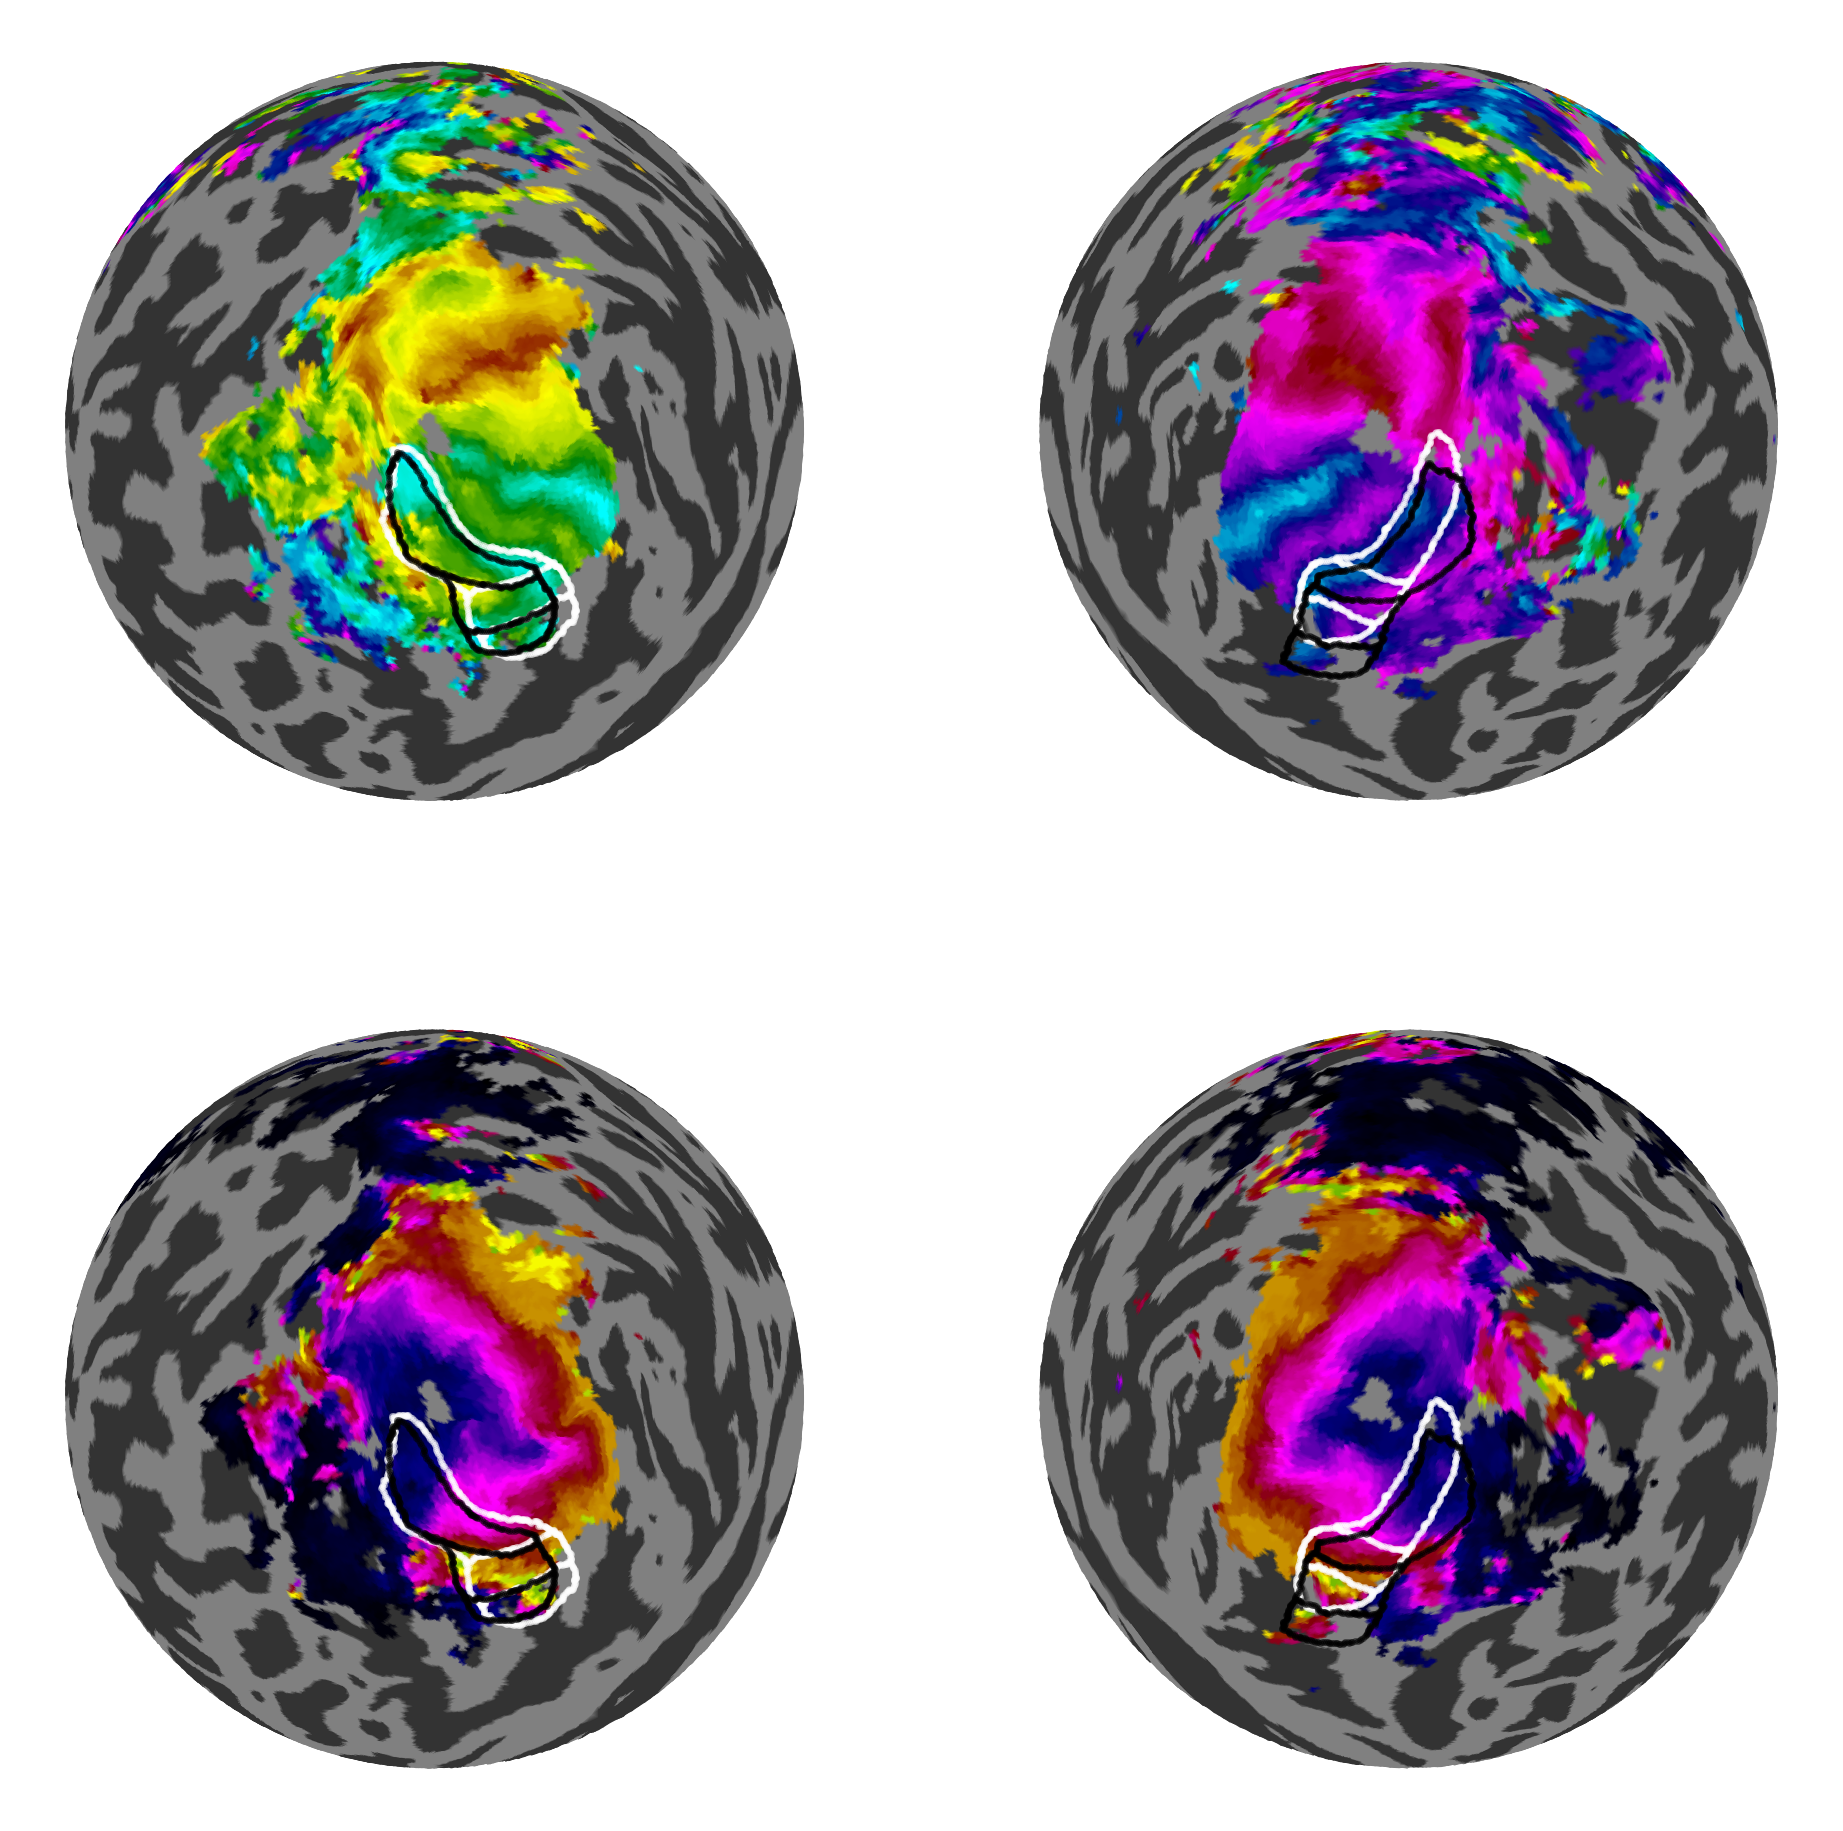

In [15]:
# Different
rater = 'A7'
for sid in val:
    fig, axs = plt.subplots(2,2, figsize=(8,8), dpi=288)
    target, index = im._to_target_index({'rater': rater, 'subject': sid})
    sub = ny.data['hcp_lines'].subjects[sid]
    labels = im.predlabels(k=index, model=model)
    for (hem, ax_col, hem_label) in zip(['lh', 'rh'], axs.T, labels):
        fmap = im.image_cache.get_flatmap(target=target, view={'hemisphere': hem})
        gold = ny.load(f"/gscratch/nbenlab/data/hcp/labels/crcns2021/mean/{sid}/{hem}.ventral_label.mgz")
        gold = gold[fmap.labels]
        u, v = fmap.tess.indexed_edges
        ii = hem_label[u] != hem_label[v]
        x1, y1 = (fmap.coordinates[:, u[ii]] + fmap.coordinates[:, v[ii]])/2
        
        ii = gold[u] != gold[v]
        x2, y2 = (fmap.coordinates[:, u[ii]] + fmap.coordinates[:, v[ii]])/2
        for (prop, ax) in zip(['polar_angle', 'eccentricity'], ax_col):
            ny.cortex_plot(fmap, color=f'prf_{prop}', mask=('prf_variance_explained', 0.05, 1), axes=ax)
            
            ax.scatter(x1, y1, c='w', s=0.5, alpha=0.5)
            
            ax.scatter(x2, y2, c='k', s=0.5, alpha=0.5)
            
            ax.axis('equal')
            ax.axis('off')
    break

In [12]:
labels

(array([0, 0, 0, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]))

In [49]:
nofn_df = pd.read_csv(os.path.join(model_cache_path, 'nofn_rater_model_dice.csv'))
t1t2_df = pd.read_csv(os.path.join(model_cache_path, 't1t2_rater_model_dice.csv'))
trac_df = pd.read_csv(os.path.join(model_cache_path, 'trac_rater_model_dice.csv'))

In [ ]:
func_df = pd.read_csv()

In [50]:
nofn_df.head()

,Rater,SID,Hemisphere,Visual Area,Dice Score
0,R1,115017,lh,hV4,0.878322
1,R1,115017,lh,VO1,0.697851
2,R1,115017,lh,VO2,0.802667
3,R1,115017,rh,hV4,0.515796
4,R1,115017,rh,VO1,0.303696


In [51]:
nofn_df.tail()

,Rater,SID,Hemisphere,Visual Area,Dice Score
925,R5,901442,lh,VO1,0.483051
926,R5,901442,lh,VO2,0.664286
927,R5,901442,rh,hV4,0.734531
928,R5,901442,rh,VO1,0.264739
929,R5,901442,rh,VO2,0.000000


In [52]:
t1t2_df.head()

,Rater,SID,Hemisphere,Visual Area,Dice Score
0,R1,115017,lh,hV4,0.844327
1,R1,115017,lh,VO1,0.697842
2,R1,115017,lh,VO2,0.817391
3,R1,115017,rh,hV4,0.480611
4,R1,115017,rh,VO1,0.529412


In [53]:
t1t2_df.tail()

,Rater,SID,Hemisphere,Visual Area,Dice Score
925,R5,901442,lh,VO1,0.335616
926,R5,901442,lh,VO2,0.625483
927,R5,901442,rh,hV4,0.667763
928,R5,901442,rh,VO1,0.222458
929,R5,901442,rh,VO2,0.000000


In [54]:
trac_df.head()

,Rater,SID,Hemisphere,Visual Area,Dice Score
0,R1,115017,lh,hV4,0.793264
1,R1,115017,lh,VO1,0.630979
2,R1,115017,lh,VO2,0.708895
3,R1,115017,rh,hV4,0.529769
4,R1,115017,rh,VO1,0.332700


In [55]:
trac_df.tail()

,Rater,SID,Hemisphere,Visual Area,Dice Score
925,R5,901442,lh,VO1,0.372315
926,R5,901442,lh,VO2,0.538745
927,R5,901442,rh,hV4,0.671523
928,R5,901442,rh,VO1,0.275930
929,R5,901442,rh,VO2,0.000000


In [56]:
nofn_rater_avg = (
    nofn_df.groupby("Rater")["Dice Score"]
      .mean()
      .sort_values(ascending=False)
)

print(nofn_rater_avg)

Rater
R2    0.536091
R4    0.534721
R5    0.512895
R1    0.512778
R3    0.503361
Name: Dice Score, dtype: float64


In [57]:
t1t2_rater_avg = (
    t1t2_df.groupby("Rater")["Dice Score"]
      .mean()
      .sort_values(ascending=False)
)

print(t1t2_rater_avg)

Rater
R2    0.525685
R4    0.520879
R1    0.511482
R5    0.510425
R3    0.505928
Name: Dice Score, dtype: float64


In [58]:
trac_rater_avg = (
    trac_df.groupby("Rater")["Dice Score"]
      .mean()
      .sort_values(ascending=False)
)

print(trac_rater_avg)

Rater
R4    0.529318
R2    0.527364
R5    0.508453
R1    0.507610
R3    0.496189
Name: Dice Score, dtype: float64


In [59]:
nofn_visual_avg = (
    nofn_df.groupby("Visual Area")["Dice Score"]
      .mean()
      .sort_values(ascending=False)
)

print(nofn_visual_avg)

Visual Area
hV4    0.652960
VO1    0.515489
VO2    0.391459
Name: Dice Score, dtype: float64


In [60]:
t1t2_visual_avg = (
    t1t2_df.groupby("Visual Area")["Dice Score"]
      .mean()
      .sort_values(ascending=False)
)

print(t1t2_visual_avg)

Visual Area
hV4    0.647496
VO1    0.514234
VO2    0.382910
Name: Dice Score, dtype: float64


In [61]:
trac_visual_avg = (
    trac_df.groupby("Visual Area")["Dice Score"]
      .mean()
      .sort_values(ascending=False)
)
print(trac_visual_avg)

Visual Area
hV4    0.662706
VO1    0.505026
VO2    0.373628
Name: Dice Score, dtype: float64


In [62]:
nofn_std_err_df = nofn_df.groupby('Visual Area')['Dice Score'].agg(
    mean='mean',
    std_error=lambda x: np.std(x, ddof=1) / np.sqrt(len(x))
).reset_index()

print(nofn_std_err_df)

  Visual Area      mean  std_error
0         VO1  0.515489   0.010393
1         VO2  0.391459   0.012892
2         hV4  0.652960   0.007719


In [64]:
t1t2_std_err_df = t1t2_df.groupby('Visual Area')['Dice Score'].agg(
    mean='mean',
    std_error=lambda x: np.std(x, ddof=1) / np.sqrt(len(x))
).reset_index()

print(t1t2_std_err_df)

  Visual Area      mean  std_error
0         VO1  0.514234   0.011151
1         VO2  0.382910   0.013206
2         hV4  0.647496   0.006607


In [65]:
trac_std_err_df = trac_df.groupby('Visual Area')['Dice Score'].agg(
    mean='mean',
    std_error=lambda x: np.std(x, ddof=1) / np.sqrt(len(x))
).reset_index()

print(trac_std_err_df)

  Visual Area      mean  std_error
0         VO1  0.505026   0.010644
1         VO2  0.373628   0.012412
2         hV4  0.662706   0.007232


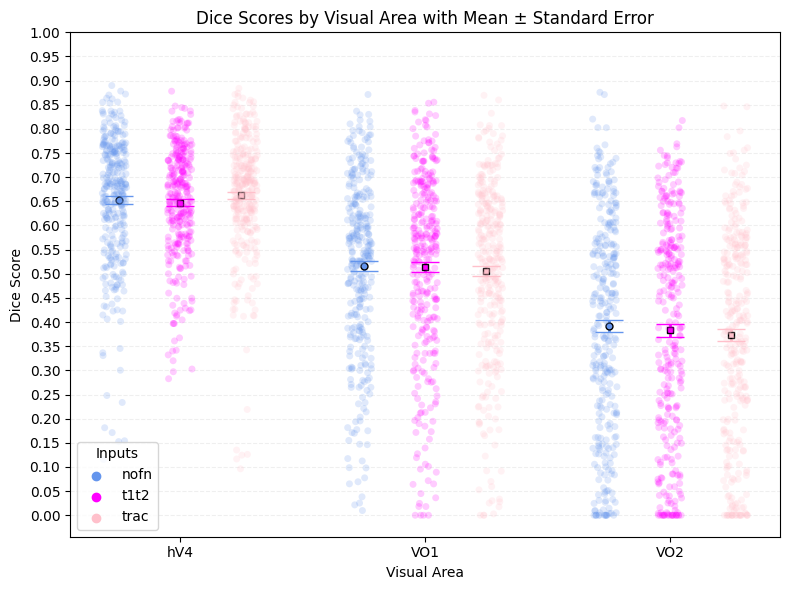

In [87]:
areas = ['hV4', 'VO1', 'VO2']
nofn = nofn_df[nofn_df['Visual Area'].isin(areas)].copy()
t1t2 = t1t2_df[t1t2_df['Visual Area'].isin(areas)].copy()
trac = trac_df[trac_df['Visual Area'].isin(areas)].copy()

nofn['Input'] = 'nofn'
t1t2['Input'] = 't1t2'
trac['Input'] = 'trac'

combined_df = pd.concat([nofn, t1t2, trac], ignore_index=True)

nofn_summary = nofn.groupby('Visual Area')['Dice Score'].agg(mean='mean', std_error='sem').loc[areas].reset_index()
t1t2_summary = t1t2.groupby('Visual Area')['Dice Score'].agg(mean='mean', std_error='sem').loc[areas].reset_index()
trac_summary = trac.groupby('Visual Area')['Dice Score'].agg(mean='mean', std_error='sem').loc[areas].reset_index()

plt.figure(figsize=(8, 6))
x_indices = np.arange(3)
shift = 0.25

sns.stripplot(
    data=combined_df, 
    x='Visual Area', 
    y='Dice Score', 
    hue='Input', 
    order=areas,
    dodge=True,
    alpha=0.2,
    palette=['cornflowerblue', 'magenta', 'pink'], 
    jitter=0.15,
    size=5
)

plt.errorbar(
    x=x_indices - shift, 
    y=nofn_summary['mean'], 
    yerr=nofn_summary['std_error'], 
    fmt='o', capsize=10, color='cornflowerblue', markersize=5, elinewidth=2, markeredgecolor='black',
    label='_nolegend_'   # Prevents duplicate legend entries
)

plt.errorbar(
    x=x_indices + 0, 
    y=t1t2_summary['mean'], 
    yerr=t1t2_summary['std_error'], 
    fmt='s', capsize=10, color='magenta', markersize=5, elinewidth=2, markeredgecolor='black',
    label='_nolegend_'
)

plt.errorbar(
    x=x_indices + shift, 
    y=trac_summary['mean'], 
    yerr=trac_summary['std_error'], 
    fmt='s', capsize=10, color='pink', markersize=5, elinewidth=2, markeredgecolor='black',
    label='_nolegend_'
)

plt.xticks(ticks=x_indices, labels=areas)
plt.yticks(np.arange(0.0, 1.05, 0.05))
plt.ylabel('Dice Score')
plt.xlabel('Visual Area')
plt.title('Dice Scores by Visual Area with Mean ± Standard Error')
plt.grid(axis='y', linestyle='--', alpha=0.2)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[0:3], labels[0:3], title="Inputs")

plt.tight_layout()
plt.show()

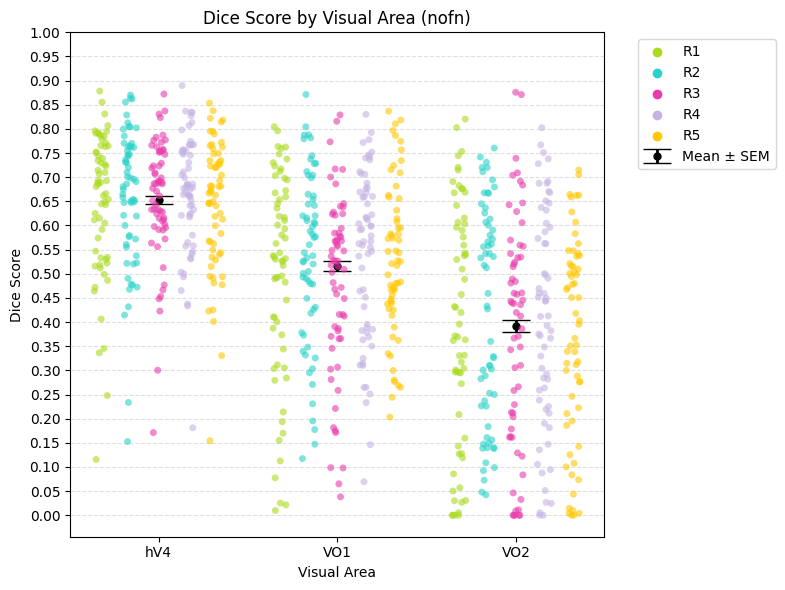

In [75]:
fig, ax = plt.subplots(figsize=(8, 6))
x_indices = np.arange(3)

areas = ['hV4', 'VO1', 'VO2']
nofn = nofn_df[nofn_df['Visual Area'].isin(areas)].copy()
nofn_summary = nofn.groupby('Visual Area')['Dice Score'].agg(mean='mean', std_error='sem').loc[areas].reset_index()

palette = {
    "R1": "#aadb1e",
    "R2": "#2ad2c9",
    "R3": "#e93cac",
    "R4": "#c5b4e3",
    "R5": "#ffc700",
}

sns.stripplot(
    data=nofn,
    x='Visual Area',
    y= 'Dice Score',
    hue="Rater",
    palette=palette,
    dodge=True,
    order=areas,
    jitter=0.2,
    size=5,
    alpha=0.6,
    ax=ax
)


ax.errorbar(
    x=x_indices,
    y=nofn_summary['mean'],
    yerr=nofn_summary['std_error'],
    fmt="o",
    color="black",
    markersize=5,
    capsize=10,
    linewidth=2,
    label="Mean ± SEM"
)

plt.yticks(np.arange(0.0, 1.05, 0.05))
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.xticks(ticks=x_indices, labels=areas)
ax.set_xlabel("Visual Area")
ax.set_ylabel("Dice Score")
ax.set_title("Dice Score by Visual Area (nofn)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

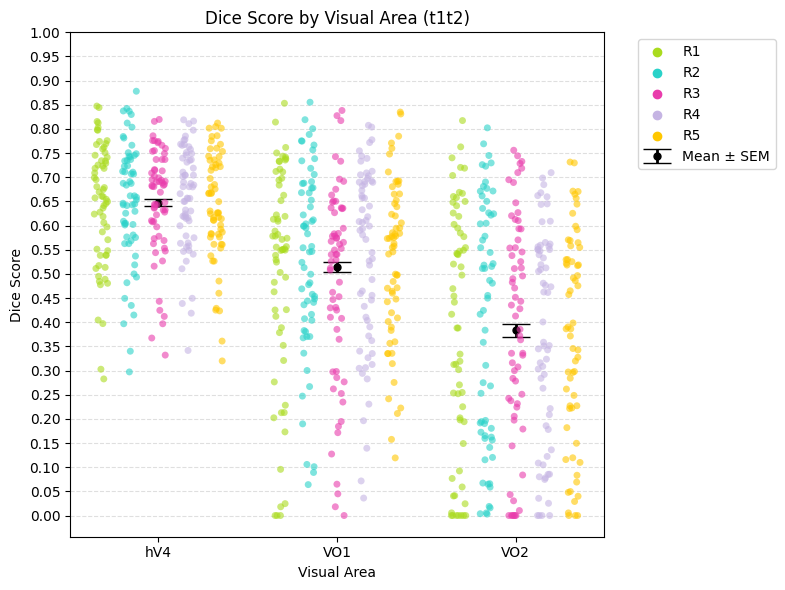

In [76]:
fig, ax = plt.subplots(figsize=(8, 6))
x_indices = np.arange(3)

areas = ['hV4', 'VO1', 'VO2']
t1t2 = t1t2_df[t1t2_df['Visual Area'].isin(areas)].copy()
t1t2_summary = t1t2.groupby('Visual Area')['Dice Score'].agg(mean='mean', std_error='sem').loc[areas].reset_index()

palette = {
    "R1": "#aadb1e",
    "R2": "#2ad2c9",
    "R3": "#e93cac",
    "R4": "#c5b4e3",
    "R5": "#ffc700",
}

sns.stripplot(
    data=t1t2,
    x='Visual Area',
    y= 'Dice Score',
    hue="Rater",
    palette=palette,
    dodge=True,
    order=areas,
    jitter=0.2,
    size=5,
    alpha=0.6,
    ax=ax
)


ax.errorbar(
    x=x_indices,
    y=t1t2_summary['mean'],
    yerr=t1t2_summary['std_error'],
    fmt="o",
    color="black",
    markersize=5,
    capsize=10,
    linewidth=2,
    label="Mean ± SEM"
)

plt.yticks(np.arange(0.0, 1.05, 0.05))
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.xticks(ticks=x_indices, labels=areas)
ax.set_xlabel("Visual Area")
ax.set_ylabel("Dice Score")
ax.set_title("Dice Score by Visual Area (t1t2)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

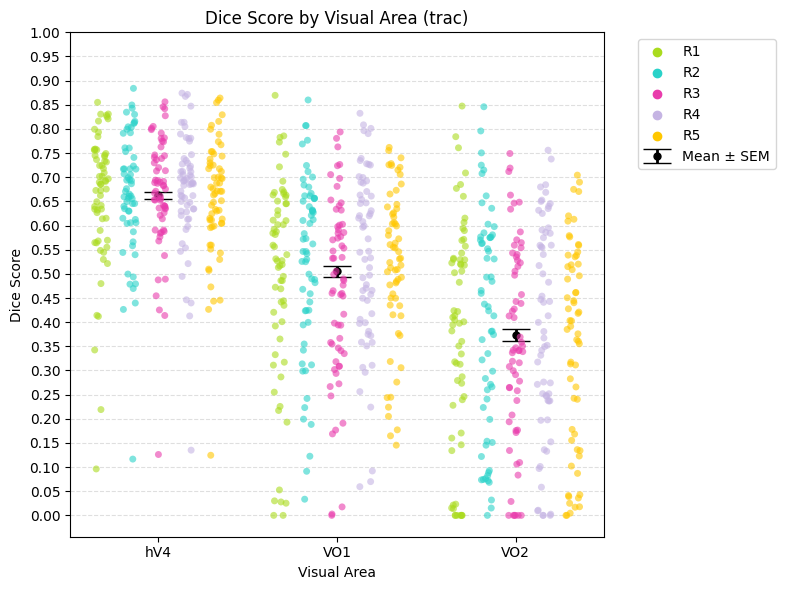

In [77]:
fig, ax = plt.subplots(figsize=(8, 6))
x_indices = np.arange(3)

areas = ['hV4', 'VO1', 'VO2']
trac = trac_df[trac_df['Visual Area'].isin(areas)].copy()
trac_summary = trac.groupby('Visual Area')['Dice Score'].agg(mean='mean', std_error='sem').loc[areas].reset_index()

palette = {
    "R1": "#aadb1e",
    "R2": "#2ad2c9",
    "R3": "#e93cac",
    "R4": "#c5b4e3",
    "R5": "#ffc700",
}

sns.stripplot(
    data=trac,
    x='Visual Area',
    y= 'Dice Score',
    hue="Rater",
    palette=palette,
    dodge=True,
    order=areas,
    jitter=0.2,
    size=5,
    alpha=0.6,
    ax=ax
)


ax.errorbar(
    x=x_indices,
    y=trac_summary['mean'],
    yerr=trac_summary['std_error'],
    fmt="o",
    color="black",
    markersize=5,
    capsize=10,
    linewidth=2,
    label="Mean ± SEM"
)

plt.yticks(np.arange(0.0, 1.05, 0.05))
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.xticks(ticks=x_indices, labels=areas)
ax.set_xlabel("Visual Area")
ax.set_ylabel("Dice Score")
ax.set_title("Dice Score by Visual Area (trac)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()